# 🏡 Seattle Airbnb Superhost Prediction: A Product-Oriented Approach

## Problem Framing (Product Perspective)

Airbnb’s platform relies heavily on **trust, quality, and user experience**. One of the strongest signals of these qualities is the **Superhost designation**, which increases visibility, bookings, and customer confidence.

From a product perspective, this raises a key question:

> **How can Airbnb identify and support hosts who are likely to become Superhosts?**

Rather than treating this purely as a machine learning problem, this project approaches it as a **product decision-making problem**, where predictive modeling is used to:

- Understand what drives host success  
- Identify actionable levers for improving user experience  
- Inform product features that increase host quality and retention  

## Objective

Build a predictive model to classify whether a host will become a Superhost, and use the results to generate **product insights and recommendations** that Airbnb could implement.

## Product Lens

This project focuses on answering:
- What behaviors lead to successful hosts?
- How can the platform guide users toward those behaviors?
- What product features could improve host outcomes?


## <u>Case Study</u>: Classifying Airbnb Superhost Status

Suppose that you have a spare room in your house (in Seattle) and you are considering advertising this room to guests on Airbnb. Airbnb superhosts are considered to be experienced hosts who provide a shining example for other hosts, and extraordinary experiences for their guests. Once a host reaches Superhost status, a superhost badge will automatically appear on their listing and profile to help guests identify them. You would like to assess your chances of being named a superhost with your property.

The following dataset is a sample (assume random) of available Airbnb listings in Seattle, WA. These listings were collected in January 2016, and filtered to just contain listings from the four most popular Seattle neighborhoods (for Airbnb listings) and just contain listings that are either in a house or apartment property.

This dataset contains the following variables.

**Listing Information**
The dataset contains the following information about the Airbnb *listing*:
* <u>price</u>: price of the listing (per night)(in US dollars)
* <u>review_scores_rating</u>: the average rating of the listing [0,100] (100 is the best)
* <u>number_of_reviews</u>: the number of reviews for the listing
* <u>security_deposit</u>: the security deposit required for the listing (in US dollars)
* <u>cleaning_fee</u>: the cleaning fee required for the listing (in US dollars)
* <u>neighborhood</u>: the neighborhood of Seattle the listing is located in
* <u>property_type</u>: is the listing in a 'House' or 'Apartment'
* <u>room_type</u>: is the listing a 'Entire home/apt', 'Private room', or 'Shared room'
* <u>accommodates</u>: how many guests will the listing accommodate
* <u>bathrooms</u>:how many bathrooms does the listing have
* <u>beds</u>: how many beds does the listing have

**Host Information**
The dataset also contains the following information about the *host* of the given Airbnb listing:
* <u>host_is_superhost</u>: is the host a "superhost": t=True, f=False
* <u>host_has_profile_pic</u>: does the host have a profile pic in their bio: t=True, f=False
* <u>host_response_time</u>: how fast will the host respond to requests (on average)

## Research Goals

### Primary Research Goal
The primary research goal that we will pursue in this lab will be to build a predictive model that effectively predicts the `probability a Seattle Airbnb host is a **superhost**` for *new Seattle Airbnb listings/hosts* given some combination of the `remaining explanatory variables`.

### Secondary Research Goal

We would also like to interpret our final model.

In [1]:
import pandas as pd                    
import matplotlib.pyplot as plt        
import seaborn as sns                 
sns.set()  

## 1. Basic Data Examination and Cleaning

### 1.1. Reading the Dataset

1. Read the `seattle_airbnb_listings.csv` file into a dataframe.

2. Display your dataframe.

3. Show how many rows your dataframe has.



In [2]:
df = pd.read_csv('seattle_airbnb_listings.csv')
df

,price,review_scores_rating,number_of_reviews,security_deposit,cleaning_fee,neighborhood,property_type,room_type,accommodates,bathrooms,beds,host_response_time,host_response_rate,host_is_superhost,host_has_profile_pic,host_identity_verified
0,300,100,24,500,95,Wallingford,House,Entire home/apt,5,1.5,3,within a few hours,1.00,t,t,t
1,149,96,11,300,105,Wallingford,Apartment,Entire home/apt,6,1.0,3,within an hour,1.00,f,t,t
2,95,95,79,150,40,Wallingford,Apartment,Entire home/apt,3,1.0,2,within an hour,1.00,f,t,t
3,105,100,13,500,50,Wallingford,House,Private room,2,2.0,1,within a few hours,1.00,t,t,t
4,140,99,30,250,65,Wallingford,House,Entire home/apt,2,1.0,1,within an hour,1.00,t,t,t
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,65,80,4,350,35,Broadway,House,Shared room,1,0.5,1,within an hour,0.90,f,t,t
288,199,97,110,500,100,Broadway,Apartment,Entire home/apt,4,1.0,2,within an hour,1.00,f,t,t
289,159,100,18,250,40,Broadway,House,Entire home/apt,4,1.0,2,within a few hours,1.00,f,t,t
290,100,86,7,95,30,Broadway,Apartment,Entire home/apt,4,1.0,2,within an hour,0.83,f,t,t


In [3]:
df.shape[0]

292

### 1.2. 0/1 Response Variable

Create a new 0/1 variable in your dataset in which `superhosts=1` and `nonsuperhosts=0`. 

In [4]:
df['superhost_or_not'] = df['host_is_superhost'].replace({'t':1, 'f':0})
df.head()

/var/folders/rd/w761h6vj4zd757g81m6stphh0000gn/T/ipykernel_18042/3225164301.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['superhost_or_not'] = df['host_is_superhost'].replace({'t':1, 'f':0})


,price,review_scores_rating,number_of_reviews,security_deposit,cleaning_fee,neighborhood,property_type,room_type,accommodates,bathrooms,beds,host_response_time,host_response_rate,host_is_superhost,host_has_profile_pic,host_identity_verified,superhost_or_not
0,300,100,24,500,95,Wallingford,House,Entire home/apt,5,1.5,3,within a few hours,1.0,t,t,t,1
1,149,96,11,300,105,Wallingford,Apartment,Entire home/apt,6,1.0,3,within an hour,1.0,f,t,t,0
2,95,95,79,150,40,Wallingford,Apartment,Entire home/apt,3,1.0,2,within an hour,1.0,f,t,t,0
3,105,100,13,500,50,Wallingford,House,Private room,2,2.0,1,within a few hours,1.0,t,t,t,1
4,140,99,30,250,65,Wallingford,House,Entire home/apt,2,1.0,1,within an hour,1.0,t,t,t,1


### 1.3. Train-Test-Split 

Create a training dataset and a test dataset from your dataframe using a random state of `207` and a test dataset size that is a random sample of about 20% of the observations from the original dataset.

In [5]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, test_size=0.2, random_state=207)

In [6]:
df_test.shape[0]/df.shape[0]

0.20205479452054795

### 1.4. Numerical Explanatory Variable Scaling

#### 1.4.1. Numerical Explanatory Variable Standard Deviations

First, calculate the standard deviation of each of your numerical explanatory variables in your training dataset.

In [7]:
df_num_train = df_train[['price','review_scores_rating','number_of_reviews', 'security_deposit', 'cleaning_fee', 'accommodates', 'bathrooms', 'beds', 'host_response_rate']]
df_num_train.std()

price                    94.549268
review_scores_rating      6.216525
number_of_reviews        37.435455
security_deposit        289.589965
cleaning_fee             42.457580
accommodates              2.110803
bathrooms                 0.559612
beds                      1.089457
host_response_rate        0.103383
dtype: float64

#### 1.4.2. Scaling the Numerical Explanatory Variables in the Training Dataset

Just like we saw in a linear regression model, if the standard deviations of the numerical explanatory variables in a logistic regression model are not all roughly equal, then we cannot interpret the magnitude of the slopes as reflecting the predictive power that the corresponding variable brings to the model.

Because we'd now like to (ideally) interpret the slope magnitudes of our model in this way, z-score scale the numerical explanatory variables in your training dataset (using the TRAINING dataset means and standard deviations.)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler_training = StandardScaler()
scaled_expl_vars = scaler_training.fit_transform(df_num_train)
df_train[['price','review_scores_rating','number_of_reviews', 'security_deposit', 'cleaning_fee', 'accommodates', 'bathrooms', 'beds', 'host_response_rate']] = scaled_expl_vars
df_train.head()

,price,review_scores_rating,number_of_reviews,security_deposit,cleaning_fee,neighborhood,property_type,room_type,accommodates,bathrooms,beds,host_response_time,host_response_rate,host_is_superhost,host_has_profile_pic,host_identity_verified,superhost_or_not
210,-0.785756,0.233855,-0.526441,0.228741,-0.550785,Broadway,House,Shared room,-1.137011,-1.268162,-0.639562,within an hour,-0.499655,f,t,t,0
22,-0.944745,-0.088561,-0.606752,0.228741,-0.550785,Wallingford,House,Shared room,-1.137011,-0.372763,-0.639562,within an hour,-0.499655,f,t,t,0
90,0.740538,0.878687,-0.713832,0.055711,0.511378,Minor,Apartment,Entire home/apt,-0.187464,1.418036,0.280302,within an hour,0.469701,f,t,t,0
125,-0.096804,0.233855,-0.312280,-0.290348,0.393360,Belltown,Apartment,Entire home/apt,-0.662237,-0.372763,-0.639562,within a day,0.469701,f,t,t,0
166,-0.149800,0.233855,-0.205200,0.055711,-0.196731,Belltown,Apartment,Entire home/apt,-0.187464,-0.372763,-0.639562,within an hour,0.469701,f,t,t,0


#### 1.4.3. Scaling the Numerical Explanatory Variables in the Test Dataset

Then, z-score scale the numerical explanatory variables in your TEST dataset (using the means and standard deviations from the TRAINING dataset).

In [9]:
df_num_test = df_test[['price','review_scores_rating','number_of_reviews', 'security_deposit', 'cleaning_fee', 'accommodates', 'bathrooms', 'beds', 'host_response_rate']]
df_num_test.std()

price                    76.614125
review_scores_rating     11.534716
number_of_reviews        37.520180
security_deposit        143.754501
cleaning_fee             32.451159
accommodates              1.746500
bathrooms                 0.426168
beds                      1.125913
host_response_rate        0.074238
dtype: float64

In [10]:
scaled_expl_vars1 = scaler_training.transform(df_num_test)
df_test[['price','review_scores_rating','number_of_reviews', 'security_deposit', 'cleaning_fee', 'accommodates', 'bathrooms', 'beds', 'host_response_rate']] = scaled_expl_vars1
df_test.head()

,price,review_scores_rating,number_of_reviews,security_deposit,cleaning_fee,neighborhood,property_type,room_type,accommodates,bathrooms,beds,host_response_time,host_response_rate,host_is_superhost,host_has_profile_pic,host_identity_verified,superhost_or_not
36,-0.944745,-1.700639,-0.633522,0.228741,-0.550785,Wallingford,House,Shared room,-1.137011,-0.372763,-0.639562,within an hour,-0.499655,f,t,t,0
122,0.221174,0.556271,-0.472901,0.055711,-0.432767,Belltown,Apartment,Entire home/apt,-0.662237,-0.372763,-0.639562,within a few hours,0.469701,t,t,t,1
155,0.433160,0.717479,-0.071349,0.055711,0.039306,Belltown,Apartment,Entire home/apt,-0.187464,-0.372763,-0.639562,within an hour,0.469701,t,t,f,1
131,0.274171,0.395063,-0.419361,-0.117319,0.865433,Belltown,Apartment,Entire home/apt,0.762082,-0.372763,1.200166,within a few hours,0.469701,t,t,t,1
92,-0.096804,0.717479,0.008962,-0.463378,-0.196731,Minor,Apartment,Entire home/apt,0.287309,-0.372763,-0.639562,within an hour,0.469701,t,t,t,1


## 📊 Product-Oriented Feature Selection

Rather than selecting features purely for statistical performance, features were chosen based on **real-world product relevance**.

Key feature categories:

### 🧑‍💼 Host Behavior
- Response rate
- Number of listings
- Activity levels

### ⭐ User Experience Signals
- Review scores
- Number of reviews
- Ratings

### 🏠 Listing Characteristics
- Price
- Availability
- Property attributes

## Why This Matters (Product Perspective)

Each feature represents a **lever Airbnb can influence through product design**:

- Reviews → can be increased via prompts and incentives  
- Ratings → can be improved via feedback systems  
- Response rate → can be improved via notifications and tools  

This ensures the model outputs are **actionable**, not just predictive.

## 2. Full Model Classification

### 2.1. Full Logistic Regression Model

First, let's fit the "full" model logistic regression model with our training dataset. In the interest of time, we'll call our "full" model the one that predicts the `probability that a host is a superhost` given the four explanatory variables below:
* `review_scores_rating`
* `number_of_reviews`
* `neighborhood`
* `property_type`


Show the summary output table for this logistic regression model.

In [11]:
import statsmodels.formula.api as smf
full_model = smf.logit(formula='superhost_or_not~number_of_reviews+review_scores_rating+neighborhood+property_type', data=df_train).fit()
full_model.summary()

Optimization terminated successfully.
         Current function value: 0.516771
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       superhost_or_not   No. Observations:                  233
Model:                          Logit   Df Residuals:                      226
Method:                           MLE   Df Model:                            6
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.1494
Time:                        23:16:03   Log-Likelihood:                -120.41
converged:                       True   LL-Null:                       -141.56
Covariance Type:            nonrobust   LLR p-value:                 1.600e-07
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.8550      0.342     -2.503      0.012      -1.524      -0.185
neighborhood[T.Broadway]       -0.7068      0.430     -1.645      0.100      -1.549       0.135
neighborhood[T.Minor]           0.2401      0.554      0.434      0.665      -0.846       1.326
neighborhood[T.Wallingford]    -0.2264      0.539     -0.420      0.674      -1.283       0.830
property_type[T.House]         -0.3188      0.409     -0.780      0.436      -1.120       0.483
number_of_reviews               0.5528      0.165      3.346      0.001       0.229       0.877
review_scores_rating            1.3901      0.350      3.968      0.000       0.703       2.077
===============================================================================================
"""

### 2.2. Test Dataset ROC Curve

Now, create an ROC curve for this logistic regression model and the **test dataset**. Also calculate the AUC of this ROC curve.

In [12]:
df_test['predictive_prob'] = full_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()

,predictive_prob,superhost_or_not
36,0.016072,0
122,0.415059,1
155,0.525719,1
131,0.368747,1
92,0.595679,1


In [13]:
from sklearn.metrics import roc_curve
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])

In [14]:
pd.DataFrame({'fpr':fprs, 'tpr':tprs})

,fpr,tpr
0,0.000000,0.000000
1,0.000000,0.047619
2,0.000000,0.190476
3,0.026316,0.190476
4,0.026316,0.428571
5,0.078947,0.428571
6,0.078947,0.476190
7,0.105263,0.476190
8,0.105263,0.619048
9,0.157895,0.619048


In [15]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc

np.float64(0.8533834586466165)

In [16]:
def plot_roc(fpr,tpr,auc,lw=2):
    plt.plot(fpr,tpr,color='darkorange',lw=lw, label='ROC curve (area='+str(round(auc,3))+')')
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

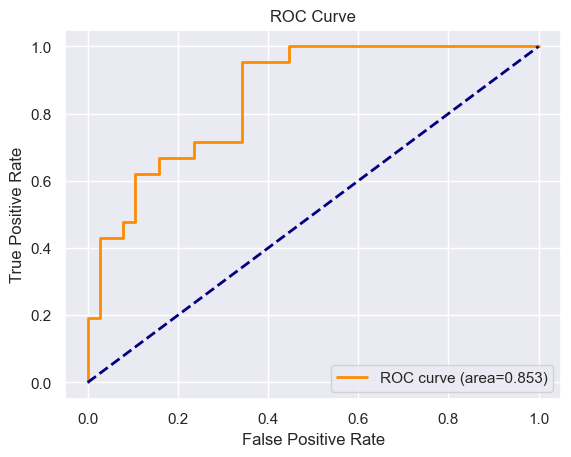

In [17]:
plot_roc(fprs,tprs,auc)

### 2.3. Interpreting the Test ROC and AUC

1. Suppose we were to use the full logistic regression model to classify the observations in the test dataset. Does there exist a predictive probability threshold that we could use that would create a classification of the test dataset with close to perfect FPR and TPR? 
2. Evaluate how well the full logistic regression model would do in general when it comes to classifying the test dataset.

1. The predictive probability has to be high enough & low enough to get classification results with these values. An ideal classifcation would have a tpr of 1 and fpr of 0 but that is not possible. We can get closer though. Given that the AUC score for this full model is close to 1 (0.853) there does exist some predictive probability threshold which will get us very close to the ideal classification (fpr, tpr)=(0,1). We would need to find the optimal threshold (by examining the ROC curve) to get close to the ideal (FPR=0, TPR=1) — the high AUC of 0.853 tells us such a threshold exists, but it must be identified empirically, not assumed to be near 0.95
2. Because our AUC score this model is close to 1 (0.853), based on our full model test data predictive probabilities, then our model would yield good predictions for new datasets.

### 2.4. Evaluating the Full Logistic Regression Model with Respect to the Primary Research Goal

Based on our analysis above, how well might the full logistic regression model do when it comes to classifying *new Airbnb hosts* as either a super host or not a superhost?

Because our AUC score this model is close to 1 (0.853), based on our full model test data predictive probabilities, then our model would yield good predictions for new Airbnb hosts as either a superhost or not a superhost. Test dataset performance is good when AUC score is high and we used test dataset as a proxy for new datasets.

## 🤖 Modeling with a Product Goal

A logistic regression model was used to predict Superhost status.

While more complex models could be applied, logistic regression was chosen because:

- It is interpretable allowing us to understand why predictions are made  
- It aligns with product needs by identifying key drivers, not just maximizing accuracy  

## Product Focus

The goal is not just prediction, but:

**Understanding which user behaviors Airbnb should encourage through product design**

This allows us to translate model outputs into **real product decisions**.

## 3. Backwards Elimination

Now let's suppose we would like to try to find the logistic regression model that will yield the **highest test dataset AUC**. Use a backwards elimination algorithm to search for the logistic regression model that will yield the **highest test dataset AUC**.

In [18]:
# drop number_of_reviews
import statsmodels.formula.api as smf
test_model = smf.logit(formula='superhost_or_not~review_scores_rating+neighborhood+property_type', data=df_train).fit()
test_model.summary()

Optimization terminated successfully.
         Current function value: 0.542234
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       superhost_or_not   No. Observations:                  233
Model:                          Logit   Df Residuals:                      227
Method:                           MLE   Df Model:                            5
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.1075
Time:                        23:16:03   Log-Likelihood:                -126.34
converged:                       True   LL-Null:                       -141.56
Covariance Type:            nonrobust   LLR p-value:                 1.208e-05
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.7081      0.331     -2.138      0.033      -1.357      -0.059
neighborhood[T.Broadway]       -0.6215      0.422     -1.475      0.140      -1.448       0.205
neighborhood[T.Minor]           0.2098      0.545      0.385      0.700      -0.858       1.277
neighborhood[T.Wallingford]    -0.3239      0.531     -0.610      0.542      -1.365       0.717
property_type[T.House]         -0.2680      0.397     -0.675      0.500      -1.046       0.510
review_scores_rating            1.0306      0.286      3.609      0.000       0.471       1.590
===============================================================================================
"""

In [19]:
df_test['predictive_prob'] = test_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()

,predictive_prob,superhost_or_not
36,0.045102,0
122,0.466342,1
155,0.507826,1
131,0.425318,1
92,0.559980,1


In [20]:
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])

In [21]:
pd.DataFrame({'fpr':fprs, 'tpr':tprs})

,fpr,tpr
0,0.000000,0.000000
1,0.026316,0.047619
2,0.026316,0.142857
3,0.052632,0.142857
4,0.052632,0.285714
5,0.052632,0.333333
6,0.052632,0.523810
7,0.078947,0.571429
8,0.157895,0.571429
9,0.210526,0.571429


In [22]:
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc

np.float64(0.8408521303258145)

In [23]:
def plot_roc(fpr,tpr,auc,lw=2):
    plt.plot(fpr,tpr,color='darkorange',lw=lw, label='ROC curve (area='+str(round(auc,3))+')')
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

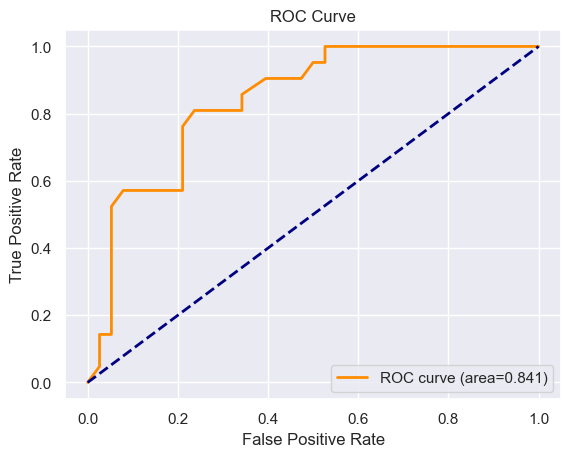

In [24]:
plot_roc(fprs,tprs,auc)

In [25]:
#drop review_scores_rating
test_model = smf.logit(formula='superhost_or_not~number_of_reviews+neighborhood+property_type', data=df_train).fit()
test_model.summary()

Optimization terminated successfully.
         Current function value: 0.569979
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       superhost_or_not   No. Observations:                  233
Model:                          Logit   Df Residuals:                      227
Method:                           MLE   Df Model:                            5
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.06185
Time:                        23:16:03   Log-Likelihood:                -132.81
converged:                       True   LL-Null:                       -141.56
Covariance Type:            nonrobust   LLR p-value:                  0.003626
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.3874      0.310     -1.249      0.212      -0.995       0.221
neighborhood[T.Broadway]       -0.9545      0.415     -2.300      0.021      -1.768      -0.141
neighborhood[T.Minor]           0.3888      0.532      0.731      0.465      -0.654       1.432
neighborhood[T.Wallingford]    -0.3602      0.523     -0.689      0.491      -1.385       0.665
property_type[T.House]         -0.3577      0.390     -0.918      0.358      -1.121       0.406
number_of_reviews               0.3625      0.144      2.513      0.012       0.080       0.645
===============================================================================================
"""

In [26]:
df_test['predictive_prob'] = test_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()

,predictive_prob,superhost_or_not
36,0.208344,0
122,0.363820,1
155,0.398128,1
131,0.368324,1
92,0.501160,1


In [27]:
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])

In [28]:
pd.DataFrame({'fpr':fprs, 'tpr':tprs})

,fpr,tpr
0,0.000000,0.000000
1,0.026316,0.000000
2,0.026316,0.142857
3,0.105263,0.142857
4,0.131579,0.190476
5,0.131579,0.238095
6,0.157895,0.238095
7,0.157895,0.523810
8,0.157895,0.619048
9,0.157895,0.666667


In [29]:
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc

np.float64(0.7901002506265665)

In [30]:
def plot_roc(fpr,tpr,auc,lw=2):
    plt.plot(fpr,tpr,color='darkorange',lw=lw, label='ROC curve (area='+str(round(auc,3))+')')
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

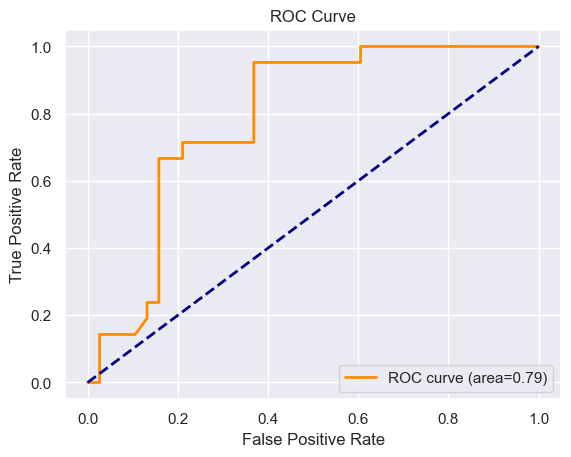

In [31]:
plot_roc(fprs,tprs,auc)

In [32]:
# drop neighborhood
test_model = smf.logit(formula='superhost_or_not~number_of_reviews+review_scores_rating+property_type', data=df_train).fit()
test_model.summary()

Optimization terminated successfully.
         Current function value: 0.528026
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       superhost_or_not   No. Observations:                  233
Model:                          Logit   Df Residuals:                      229
Method:                           MLE   Df Model:                            3
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.1309
Time:                        23:16:03   Log-Likelihood:                -123.03
converged:                       True   LL-Null:                       -141.56
Covariance Type:            nonrobust   LLR p-value:                 4.467e-08
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1.1924      0.234     -5.099      0.000      -1.651      -0.734
property_type[T.House]    -0.1606      0.320     -0.502      0.616      -0.788       0.466
number_of_reviews          0.5255      0.164      3.203      0.001       0.204       0.847
review_scores_rating       1.4889      0.343      4.345      0.000       0.817       2.161
==========================================================================================
"""

In [33]:
df_test['predictive_prob'] = test_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()

,predictive_prob,superhost_or_not
36,0.014514,0
122,0.351445,1
155,0.459675,1
131,0.304791,1
92,0.470173,1


In [34]:
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])

In [35]:
pd.DataFrame({'fpr':fprs, 'tpr':tprs})

,fpr,tpr
0,0.000000,0.000000
1,0.000000,0.047619
2,0.000000,0.333333
3,0.052632,0.333333
4,0.052632,0.428571
5,0.078947,0.428571
6,0.078947,0.523810
7,0.131579,0.523810
8,0.157895,0.523810
9,0.157895,0.571429


In [36]:
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc

np.float64(0.7994987468671679)

In [37]:
def plot_roc(fpr,tpr,auc,lw=2):
    plt.plot(fpr,tpr,color='darkorange',lw=lw, label='ROC curve (area='+str(round(auc,3))+')')
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

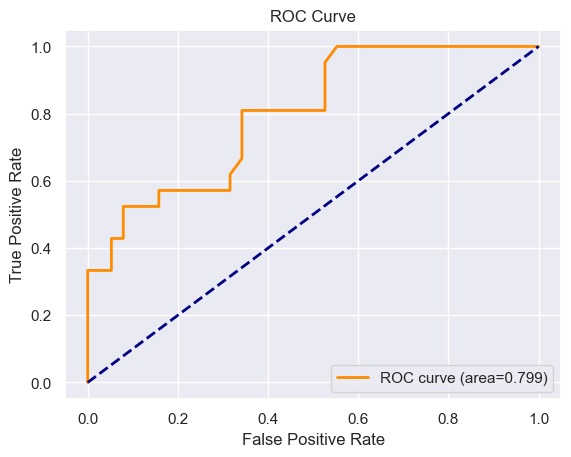

In [38]:
plot_roc(fprs,tprs,auc)

In [39]:
# drop property_type
test_model = smf.logit(formula='superhost_or_not~number_of_reviews+review_scores_rating+neighborhood', data=df_train).fit()
test_model.summary()

Optimization terminated successfully.
         Current function value: 0.518086
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       superhost_or_not   No. Observations:                  233
Model:                          Logit   Df Residuals:                      227
Method:                           MLE   Df Model:                            5
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.1473
Time:                        23:16:03   Log-Likelihood:                -120.71
converged:                       True   LL-Null:                       -141.56
Covariance Type:            nonrobust   LLR p-value:                 6.796e-08
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.8542      0.341     -2.503      0.012      -1.523      -0.185
neighborhood[T.Broadway]       -0.7834      0.420     -1.867      0.062      -1.606       0.039
neighborhood[T.Minor]           0.0029      0.463      0.006      0.995      -0.905       0.911
neighborhood[T.Wallingford]    -0.4396      0.466     -0.944      0.345      -1.353       0.474
number_of_reviews               0.5488      0.165      3.331      0.001       0.226       0.872
review_scores_rating            1.3886      0.349      3.980      0.000       0.705       2.072
===============================================================================================
"""

In [40]:
df_test['predictive_prob'] = test_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()

,predictive_prob,superhost_or_not
36,0.017935,0
122,0.415490,1
155,0.525706,1
131,0.369170,1
92,0.537397,1


In [41]:
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])

In [42]:
pd.DataFrame({'fpr':fprs, 'tpr':tprs})

,fpr,tpr
0,0.000000,0.000000
1,0.000000,0.047619
2,0.000000,0.380952
3,0.052632,0.380952
4,0.052632,0.523810
5,0.078947,0.523810
6,0.078947,0.571429
7,0.131579,0.571429
8,0.131579,0.619048
9,0.184211,0.619048


In [43]:
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc

np.float64(0.8609022556390977)

In [44]:
def plot_roc(fpr,tpr,auc,lw=2):
    plt.plot(fpr,tpr,color='darkorange',lw=lw, label='ROC curve (area='+str(round(auc,3))+')')
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

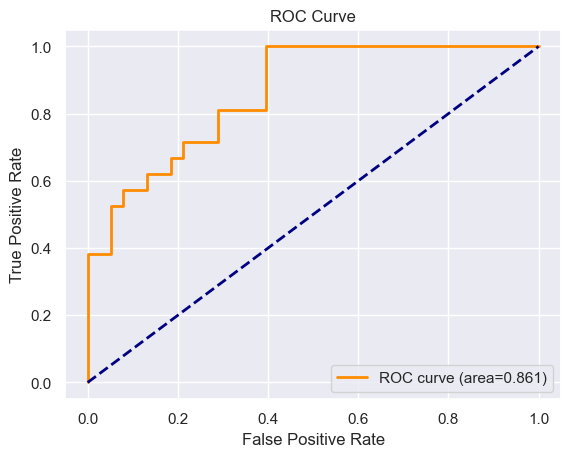

In [45]:
plot_roc(fprs,tprs,auc)

Permanently drop `property_type` because removing it yields the largest AUC improvement among all single-variable drops, indicating it was overfitting the training data. Continue backwards elimination with the remaining variables.


In [46]:
# drop property_type permanently — confirm final reduced model
new_model = smf.logit(formula='superhost_or_not~number_of_reviews+review_scores_rating+neighborhood', data=df_train).fit()
df_test['predictive_prob'] = new_model.predict(df_test)
auc = roc_auc_score(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])
auc


Optimization terminated successfully.
         Current function value: 0.518086
         Iterations 7


np.float64(0.8609022556390977)

Optimization terminated successfully.
         Current function value: 0.543220
         Iterations 7


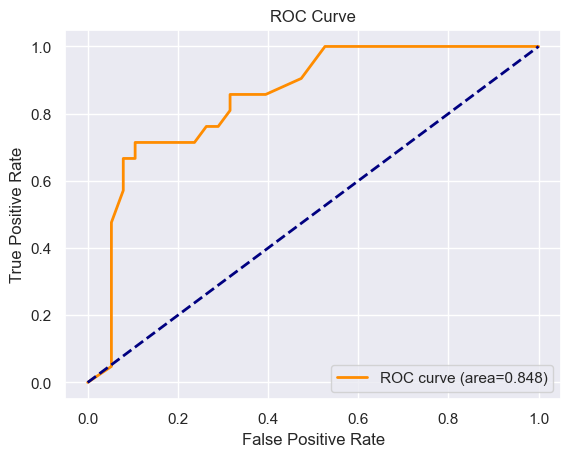

In [47]:
# drop property_type permanently, drop number_of_reviews
test_model = smf.logit(formula='superhost_or_not~review_scores_rating+neighborhood', data=df_train).fit()
df_test['predictive_prob'] = test_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc
def plot_roc(fpr,tpr,auc,lw=2):
    plt.plot(fpr,tpr,color='darkorange',lw=lw, label='ROC curve (area='+str(round(auc,3))+')')
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
plot_roc(fprs,tprs,auc)

Optimization terminated successfully.
         Current function value: 0.571808
         Iterations 5


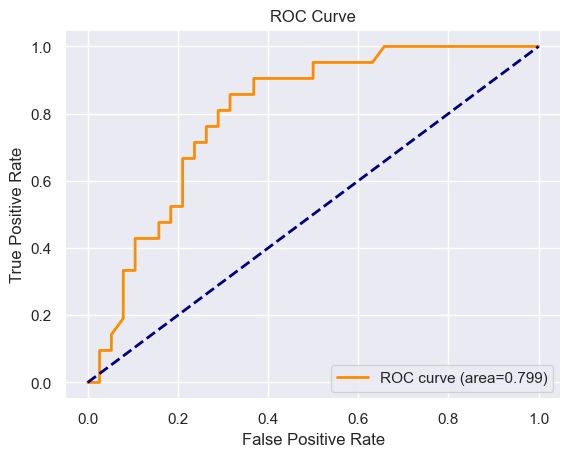

In [48]:
# drop property_type permanently, drop review_scores_rating
test_model = smf.logit(formula='superhost_or_not~number_of_reviews+neighborhood', data=df_train).fit()
df_test['predictive_prob'] = test_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc
def plot_roc(fpr,tpr,auc,lw=2):
    plt.plot(fpr,tpr,color='darkorange',lw=lw, label='ROC curve (area='+str(round(auc,3))+')')
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
plot_roc(fprs,tprs,auc)

Optimization terminated successfully.
         Current function value: 0.528569
         Iterations 7


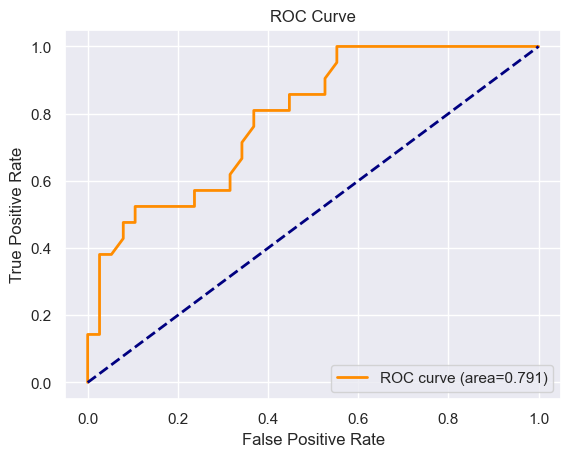

In [49]:
# drop property_type permanently, drop neighborhood
test_model = smf.logit(formula='superhost_or_not~number_of_reviews+review_scores_rating', data=df_train).fit()
df_test['predictive_prob'] = test_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc
def plot_roc(fpr,tpr,auc,lw=2):
    plt.plot(fpr,tpr,color='darkorange',lw=lw, label='ROC curve (area='+str(round(auc,3))+')')
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
plot_roc(fprs,tprs,auc)

Dropping any other variables alongside property_type does not increase our AUC score, so we stop the algorithm.

## 4. Selecting the Best Final Model Classification

Now, we would like to use our final logistic regression model that we selected in #3 to create a classification that best meets our research goals.

### 4.1. Test ROC and AUC

Plot the ROC curve for this final logistic regression model and the test dataset.

Optimization terminated successfully.
         Current function value: 0.518086
         Iterations 7


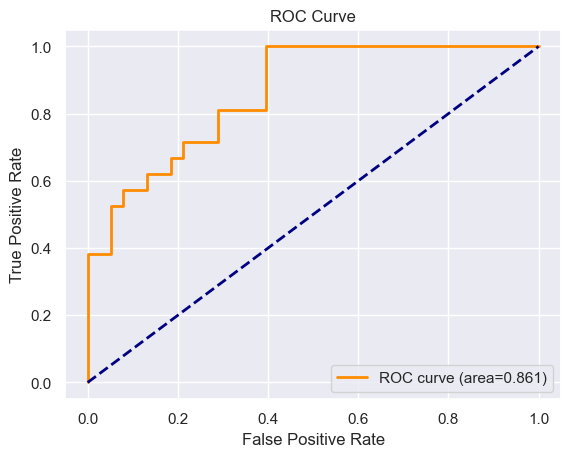

In [50]:
# drop property_type permanently
test_model = smf.logit(formula='superhost_or_not~number_of_reviews+review_scores_rating+neighborhood', data=df_train).fit()
df_test['predictive_prob'] = test_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc
def plot_roc(fpr,tpr,auc,lw=2):
    plt.plot(fpr,tpr,color='darkorange',lw=lw, label='ROC curve (area='+str(round(auc,3))+')')
    plt.plot([0,1],[0,1],color='navy',lw=lw,linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()
plot_roc(fprs,tprs,auc)

In [57]:
test_model = smf.logit(formula='superhost_or_not~number_of_reviews+review_scores_rating+neighborhood', data=df_train).fit()
df_test['predictive_prob'] = test_model.predict(df_test)
df_test[['predictive_prob','superhost_or_not']].head()
fprs, tprs, thresholds = roc_curve(y_true=df_test['superhost_or_not'], y_score=df_test['predictive_prob'])
auc = roc_auc_score(y_true=df_test['superhost_or_not'],y_score=df_test['predictive_prob'])
auc

Optimization terminated successfully.
         Current function value: 0.518086
         Iterations 7


np.float64(0.8609022556390977)

## 🔑 Key Findings

The most important predictors of Superhost status were:

- **Review Scores** → strongest indicator of host quality  
- **Number of Reviews** → reflects trust and credibility  
- **Neighborhood / Location** → indicates that geographic desirability and market dynamics significantly impact host success  
- **Host Engagement Metrics** → consistency and responsiveness  

## 🧠 Product Interpretation

These findings suggest that:

> Superhost success is driven by a combination of **user experience (reviews), trust signals (volume), and market positioning (location)**

From a product perspective:
- Some factors (reviews, engagement) are **controllable through product design**
- Others (location) are **not directly controllable**, but can inform platform strategy

### 4.2. Specific Classifier Use Case - Explaining My Thought Processes

Suppose that you work as a data scientist at Airbnb. Suppose that research from another data scientist team within the company has suggested that there may have been a "superhost-inflation" effect occurring within the company over the last few years. Specifically this team has suggested that too many hosts have been receiving the status of superhost, because the level of quality that these hosts are providing to their guests does not warrant the elevated status that is being bestowed upon them by Airbnb. Thus, in an attempt to give the guests a better quality experience, you would ideally like for a **high amount of the people in this dataset who are NOT already superhosts to NOT be awarded (ie. predicted) to NOT be a superhost**. On the other hand becauase you think that there is a "superhost-inflation" effect going on, Airbnb has decided that it is not as big of a deal if people who are superhosts in this dataset to NOT be awarded (ie. predicted) to be a superhost. However, your boss has also decided that **at most 40% of superhosts should be expected to be misclassified as a non-superhost in new datasets.**

Practically speaking you'd be classifying hosts as superhosts vs. nonsuperhosts for *new datasets*.

1. If we were to use the final logistic regression from #3, what predictive probability threshold should we use to create a classification that best meets these specific research goals and specifications? 
2. What false positive rate and true positive rate would the test dataset classification have if we were to use this predictive probability threshold?



In [52]:
from sklearn.metrics import confusion_matrix
def fpr_tpr_thresh(superhost_or_not, pred_prob, thresh):
    yhat = 1*(pred_prob >= thresh)
    tn, fp, fn, tp = confusion_matrix(y_true=superhost_or_not, y_pred=yhat).ravel()
    tpr = tp/(fn+tp)
    fpr = fp/(fp+tn)
    return pd.DataFrame({'threshold':[thresh], 'fpr':[fpr], 'tpr':[tpr]})

In [53]:
fpr_tpr_thresh(df_test['superhost_or_not'],df_test['predictive_prob'],0.5)

,threshold,fpr,tpr
0,0.5,0.0,0.380952


In [54]:
import numpy as np
for thresh in np.arange(0,1.01,0.01):
    print(fpr_tpr_thresh(df_test['superhost_or_not'], df_test['predictive_prob'], thresh))

   threshold  fpr  tpr
0        0.0  1.0  1.0
   threshold       fpr  tpr
0       0.01  0.868421  1.0
   threshold       fpr  tpr
0       0.02  0.842105  1.0
   threshold       fpr  tpr
0       0.03  0.842105  1.0
   threshold       fpr  tpr
0       0.04  0.842105  1.0
   threshold       fpr  tpr
0       0.05  0.763158  1.0
   threshold       fpr  tpr
0       0.06  0.763158  1.0
   threshold       fpr  tpr
0       0.07  0.684211  1.0
   threshold       fpr  tpr
0       0.08  0.684211  1.0
   threshold       fpr  tpr
0       0.09  0.657895  1.0
   threshold       fpr  tpr
0        0.1  0.631579  1.0
   threshold       fpr  tpr
0       0.11  0.631579  1.0
   threshold       fpr  tpr
0       0.12  0.578947  1.0
   threshold       fpr  tpr
0       0.13  0.578947  1.0
   threshold       fpr  tpr
0       0.14  0.578947  1.0
   threshold       fpr  tpr
0       0.15  0.578947  1.0
   threshold       fpr  tpr
0       0.16  0.578947  1.0
   threshold       fpr  tpr
0       0.17  0.578947  1.0
  

1. We use a predictive probability threshold of **0.36** because it satisfies the constraint that at most 40% of true superhosts are misclassified as non-superhosts (i.e., TPR ≥ 0.60). Among all thresholds meeting this constraint, 0.36 minimizes the false positive rate at 0.1316, meaning fewer non-superhosts are incorrectly labeled as superhosts.

2. At threshold = 0.36: **TPR = 0.619** and **FPR = 0.132**


### 4.3. Specificity and Sensitivity

What is the specificity and sensitivity of the test dataset classification was selected in #4.2?

specificity = 1-FPR = 1- 0.131579 = 0.868421

sensitivity = TPR = 0.619048

## 5. Interpreting the Final Logistic Regression Model

Finally, let's interpret the final logistic regression model selected in #3.

### 5.1. Logistic Regression Equation

In [55]:
test_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       superhost_or_not   No. Observations:                  233
Model:                          Logit   Df Residuals:                      227
Method:                           MLE   Df Model:                            5
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                  0.1473
Time:                        23:16:04   Log-Likelihood:                -120.71
converged:                       True   LL-Null:                       -141.56
Covariance Type:            nonrobust   LLR p-value:                 6.796e-08
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.8542      0.341     -2.503      0.012      -1.523      -0.185
neighborhood[T.Broadway]       -0.7834      0.420     -1.867      0.062      -1.606       0.039
neighborhood[T.Minor]           0.0029      0.463      0.006      0.995      -0.905       0.911
neighborhood[T.Wallingford]    -0.4396      0.466     -0.944      0.345      -1.353       0.474
number_of_reviews               0.5488      0.165      3.331      0.001       0.226       0.872
review_scores_rating            1.3886      0.349      3.980      0.000       0.705       2.072
===============================================================================================
"""

Probability:

$\hat{p}$ = $\frac{1}{1+\exp(-(-0.854	

-0.7834	* neighborhood[T.Broadway]	

+0.0029 * neighborhood[T.Minor]	

-0.4396	* neighborhood[T.Wallingford]	

+0.5488	* number_of_reviews

+1.3886 * review_scores_rating)}$

### 5.2. Final Model Multicollinearity

Does your final model have an issue with multicollinearity? Explain.

In [56]:
df_train[['number_of_reviews','review_scores_rating']].corr()

,number_of_reviews,review_scores_rating
number_of_reviews,1.00000,0.00122
review_scores_rating,0.00122,1.00000


There is no issue with multicollinearity because our numerical explanatory variables do not have a strong linear relationship and dont have a correlation greater than 0.7

### 5.3. Predictive Power

Finally, what three explanatory (or indicator) variables are suggested to bring the most predictive power to the final model? Do you have any concerns about making this interpretation?

The three explanatory variables with the highest slope magnitudes in the final model are **neighborhood[T.Broadway]**, **review_scores_rating**, and **number_of_reviews**, suggesting they contribute the most predictive power. There are no concerns about interpreting these magnitudes since we confirmed there is no multicollinearity issue (correlation between numerical variables is well below 0.7).


### 5.4. Overfitting Variables

Based on the results of our backwards elimination algorithm, do you have any reason to believe that any of the explanatory variables in the full model were overfitting the model? If so, which one(s)?

`property_type` was likely overfitting the model. Dropping it yielded the largest AUC improvement during backwards elimination, indicating the variable was capturing noise in the training data rather than a true signal generalizable to new observations.


## 🚀 Product Recommendations

Based on the model findings, several product opportunities emerge:

### 1. Increase Review Generation (Growth Lever)

**Insight:** Number of reviews strongly predicts Superhost status  

**Product Ideas:**
- Post-stay prompts encouraging guests to leave reviews  
- Incentives (discounts, credits) for completed reviews  
- Simplified review UX (fewer clicks, mobile-first)

---

### 2. Improve Review Quality (Experience Lever)

**Insight:** Review scores are the strongest predictor of success  

**Product Ideas:**
- Real-time feedback dashboards for hosts  
- AI-powered suggestions to improve listings  
- Alerts for declining ratings

---

### 3. Early Identification of High-Potential Hosts

**Insight:** Model can predict future Superhosts  

**Product Ideas:**
- “Emerging Superhost” program  
- Personalized onboarding and coaching  
- Targeted feature rollouts for high-potential users  

---

### 4. Host Engagement Optimization

**Insight:** Consistent engagement correlates with success  

**Product Ideas:**
- Response-time reminders  
- Smart notifications for booking opportunities  
- Gamification of host performance metrics  
---

### 5. Location-Aware Product Strategy

**Insight:** Neighborhood significantly impacts Superhost likelihood  

**Product Ideas:**
- Provide **location-based performance benchmarks** for hosts  
- Offer **dynamic pricing recommendations** based on neighborhood trends  
- Highlight “high-performing areas” to guide new hosts  
- Adjust ranking algorithms to account for location disadvantages  

## Product Takeaway

While Airbnb cannot change location, it can:
- Help hosts **optimize within their market**
- Provide **contextual insights and tools**

## ✅ Conclusion

This project demonstrates how machine learning can be used not just for prediction, but for **product decision-making**.

By identifying the key drivers of Superhost status, we can:

- Understand what creates value for users  
- Design features that reinforce those behaviors  
- Improve both user experience and business outcomes  

Ultimately, this approach bridges the gap between **data science and product management**, turning insights into actionable product strategy.